In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import brier_score_loss, mean_absolute_error, roc_auc_score

import json

# 1. EDA

### 1.1. Understanding grid_history dataset

In [26]:
# 1. Load the generated data
df = pd.read_csv("grid_history.csv", parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

In [27]:
df

,load_mw,temp_c,humidity,wind_ms,rain_mm,outage,duration_min
timestamp,,,,,,,
2023-01-01 00:00:00,44.665256,24.980126,76.170449,4.090472,2.489536,0,0.0
2023-01-01 01:00:00,46.666745,26.186830,52.295752,4.044980,1.149881,0,0.0
2023-01-01 02:00:00,55.420128,28.720283,71.433615,2.062047,0.278039,0,0.0
2023-01-01 03:00:00,63.938970,27.458855,61.848587,4.598648,0.936121,0,0.0
2023-01-01 04:00:00,58.331426,28.567608,62.521949,1.543142,3.504961,0,0.0
...,...,...,...,...,...,...,...
2023-06-29 19:00:00,80.049943,19.002613,50.052283,2.238544,0.547449,0,0.0
2023-06-29 20:00:00,71.380849,21.944557,53.810112,3.656506,0.329264,0,0.0
2023-06-29 21:00:00,85.836247,20.328830,67.887540,1.686728,2.254217,0,0.0


In [28]:
df.describe()

,load_mw,temp_c,humidity,wind_ms,rain_mm,outage,duration_min
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000
mean,61.792832,24.985428,59.910678,3.030538,1.523693,0.039352,4.048192
std,21.607033,3.673403,9.774154,1.005542,1.665893,0.194453,24.867134
min,6.771426,16.833217,20.775997,0.031632,0.000110,0.000000,0.000000
25%,44.928615,21.605389,53.406330,2.342948,0.425434,0.000000,0.000000
50%,60.638013,25.027272,59.926318,3.031576,1.005015,0.000000,0.000000
75%,76.897852,28.339496,66.419789,3.715673,2.014292,0.000000,0.000000
max,120.421260,32.942539,93.777682,7.479084,15.013087,1.000000,557.118876


In [35]:

# Outage Rate
outage_rate = df['outage'].mean() * 100

display("Outage Rate")
display(f"{outage_rate:.2f} %")


duration_stats = df[df['outage'] == 1]['duration_min'].describe().to_frame()

display("⏱️ Duration Stats (Outage Only - minutes)")
display(duration_stats)



# Load Stats

load_stats = df['load_mw'].describe().to_frame()

display("⚡ Load (MW) Statistics")
display(load_stats)

'Outage Rate'

'3.94 %'

'⏱️ Duration Stats (Outage Only - minutes)'

,duration_min
count,170.000000
mean,102.871691
std,74.679395
min,20.951995
25%,54.910261
50%,86.584386
75%,124.459935
max,557.118876


'⚡ Load (MW) Statistics'

,load_mw
count,4320.000000
mean,61.792832
std,21.607033
min,6.771426
25%,44.928615
50%,60.638013
75%,76.897852
max,120.421260


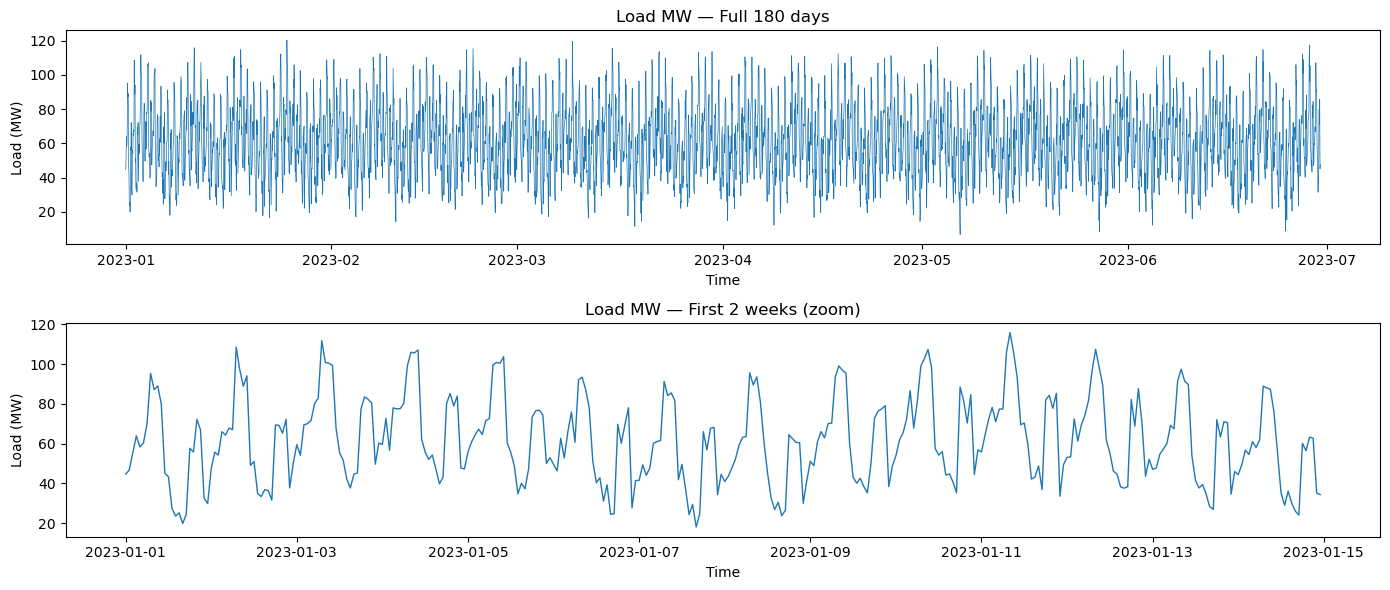

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Full series
axes[0].plot(df.index, df["load_mw"], linewidth=0.5)
axes[0].set_title("Load MW — Full 180 days")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Load (MW)")

# Zoom: first 2 weeks
mask = df.index < "2023-01-15"
axes[1].plot(df.loc[mask].index, df.loc[mask, "load_mw"], linewidth=1)
axes[1].set_title("Load MW — First 2 weeks (zoom)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Load (MW)")

plt.tight_layout()
plt.show()

## ⚡ Insights from Load MW Time Series

- The load shows a **strong daily cyclical pattern**, indicating regular demand cycles.
- There is **no clear long-term upward or downward trend**, suggesting relatively stable demand over the 180-day period.
- The series exhibits **high short-term variability**, with frequent fluctuations and sudden spikes.
- Load values range widely (≈10 MW to 120 MW), with occasional **peak demand events**.
- The pattern is **consistent across months**, with no strong seasonal shift observed.
- The zoomed view confirms a **stable and repeating daily structure**, useful for forecasting.

**Overall:** The load behavior is highly cyclical and short-term volatile, but stable in the long run.

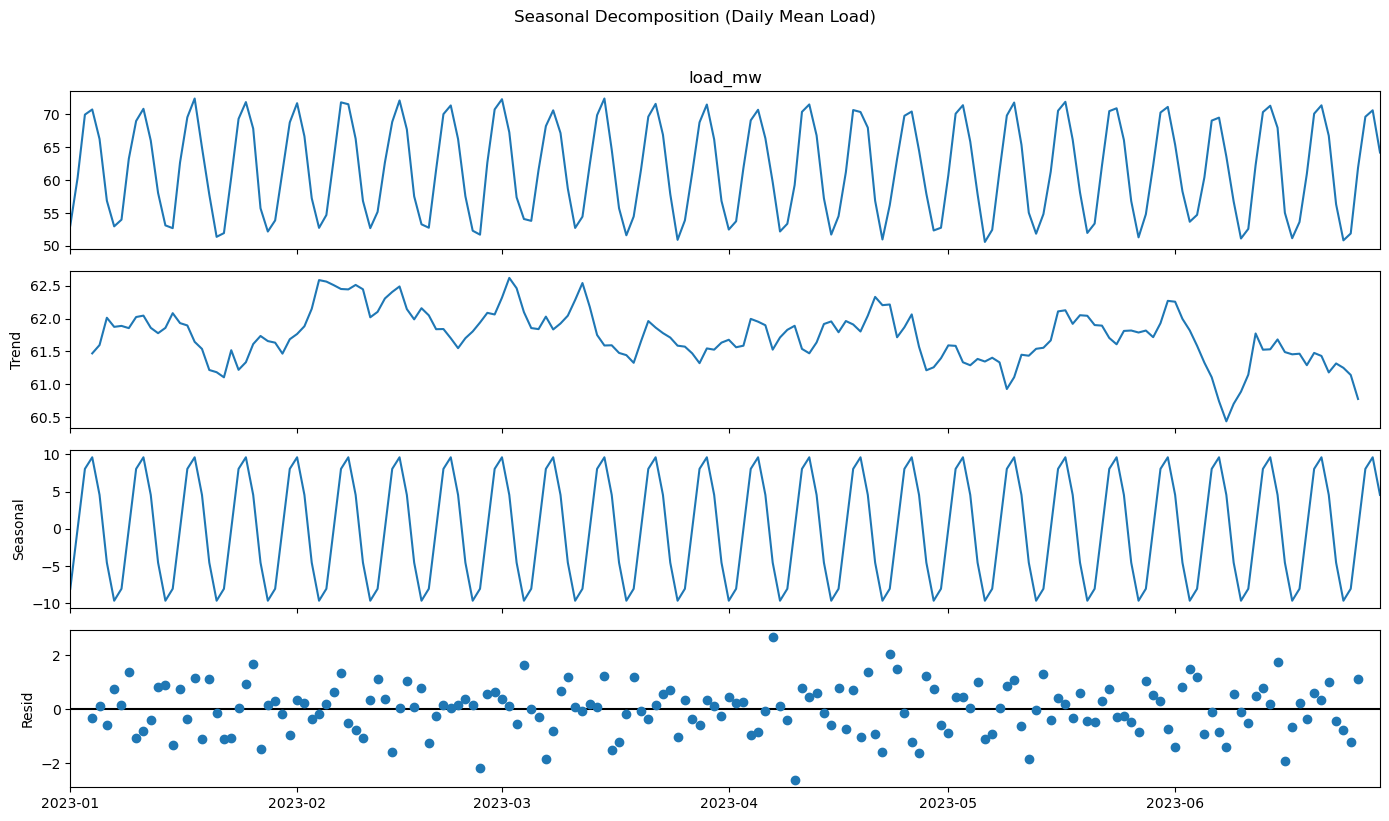

In [42]:
# Resample to daily mean for cleaner decomposition
daily = df["load_mw"].resample("D").mean()

decomp = seasonal_decompose(daily, model="additive", period=7)  # weekly period

fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Seasonal Decomposition (Daily Mean Load)", y=1.02)
plt.tight_layout()
plt.show()

The seasonal decomposition of the daily mean load reveals a highly predictable and stable energy consumption pattern characterized by a dominant weekly seasonality. The raw data fluctuates consistently between $50$ and $72$ MW, driven largely by a recurring $7$-day cycle that swings approximately $\pm10$ MW, likely reflecting the standard difference between weekday industrial demand and weekend troughs. While the trend component shows a slight, non-linear decline from roughly $62.5$ MW in early spring to $60.5$ MW by June, the residuals remain tightly clustered near zero

In [43]:
result = adfuller(df["load_mw"].dropna())

print("Augmented Dickey-Fuller Test")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical values: {result[4]}")

if result[1] < 0.05:
    print("\n✅ Series is STATIONARY → d = 0")
else:
    print("\n⚠️ Series is NON-STATIONARY → try d = 1")

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -9.8487
p-value       : 0.0000
Critical values: {'1%': np.float64(-3.431875937258768), '5%': np.float64(-2.862214274623216), '10%': np.float64(-2.567128921428161)}

✅ Series is STATIONARY → d = 0


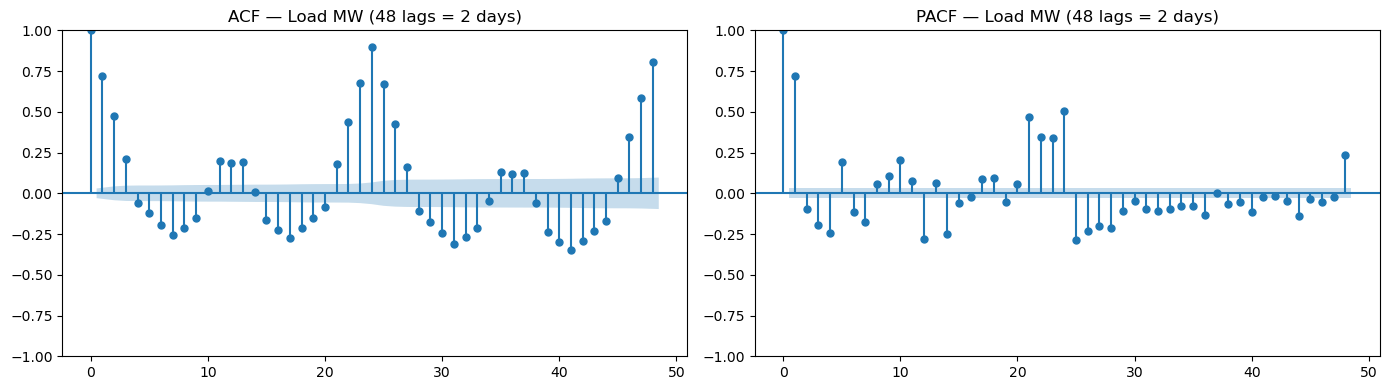

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["load_mw"].dropna(), lags=48, ax=axes[0])
axes[0].set_title("ACF — Load MW (48 lags = 2 days)")

plot_pacf(df["load_mw"].dropna(), lags=48, ax=axes[1])
axes[1].set_title("PACF — Load MW (48 lags = 2 days)")

plt.tight_layout()
plt.show()


**ACF and PACF Analysis**

Based on the statistical plots provided for the **Load MW** data, the following parameters are identified for the SARIMA $(p, d, q)(P, D, Q)_s$ model:

| Component | Parameter | Value | Statistical Evidence |
| :--- | :--- | :---: | :--- |
| **Non-Seasonal AR** | **$p$** | **2** | The **PACF** shows two distinct, significant spikes at Lag 1 and Lag 2 before cutting off into the noise. |
| **Non-Seasonal MA** | **$q$** | **0** | The **ACF** shows a geometric decay (tailing off) rather than a sharp cutoff after specific lags. |
| **Seasonality** | **$s$** | **24** | Both plots exhibit massive, recurring spikes at **Lag 24** and **Lag 48**, confirming a strong daily cycle. |

---

#### **Interpretation & Strategy**
1. **Model Baseline:** Start with a **SARIMA $(2, 0, 0)(P, D, Q)_{24}$**.
3. **Seasonal Terms:** The strong spike at Lag 24 in the PACF suggests starting with a seasonal AR term ($P=1$).

# 2. Feature Engineering

In [49]:
def make_features(df):
    df = df.copy()
    df=df.reset_index()
    df["hour"]       = df["timestamp"].dt.hour
    df["dayofweek"]  = df["timestamp"].dt.dayofweek
    df["month"]      = df["timestamp"].dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Lag features
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"load_lag{lag}"]   = df["load_mw"].shift(lag)
        df[f"outage_lag{lag}"] = df["outage"].shift(lag)

    # Rolling features
    df["load_roll6"]  = df["load_mw"].shift(1).rolling(6).mean()
    df["load_roll24"] = df["load_mw"].shift(1).rolling(24).mean()

    df = df.dropna().reset_index(drop=True)
    return df

df_feat = make_features(df)

FEATURES = [
    "hour", "dayofweek", "month", "is_weekend",
    "load_lag1", "load_lag2", "load_lag3", "load_lag6", "load_lag12", "load_lag24",
    "outage_lag1", "outage_lag6", "outage_lag24",
    "load_roll6", "load_roll24",
    "temp_c", "humidity", "wind_ms", "rain_mm"
]

TARGET_CLF = "outage"
TARGET_REG = "duration_min"

print(f"Dataset shape after features: {df_feat.shape}")

Dataset shape after features: (4296, 26)


In [50]:
split_date = df_feat["timestamp"].max() - pd.Timedelta(days=30)

train = df_feat[df_feat["timestamp"] <= split_date]
test  = df_feat[df_feat["timestamp"] >  split_date]

X_train = train[FEATURES]
X_test  = test[FEATURES]

y_clf_train = train[TARGET_CLF]
y_clf_test  = test[TARGET_CLF]

y_reg_train = train.loc[train["outage"]==1, TARGET_REG]
X_reg_train = train.loc[train["outage"]==1, FEATURES]

print(f"Train: {train.shape[0]} rows | Test: {test.shape[0]} rows")
print(f"Outage rate train: {y_clf_train.mean():.3f} | test: {y_clf_test.mean():.3f}")

Train: 3576 rows | Test: 720 rows
Outage rate train: 0.039 | test: 0.040


# 3. Modeling

### 3.1 Model 1: XGBoost

In [53]:

xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                         use_label_encoder=False, eval_metric="logloss",
                         random_state=42)
xgb_clf.fit(X_train, y_clf_train)
xgb_p = xgb_clf.predict_proba(X_test)[:, 1]

xgb_reg = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                        random_state=42)
xgb_reg.fit(X_reg_train, y_reg_train)
xgb_dur = xgb_reg.predict(X_test)

C:\Users\gabriel.ntwari\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [12:16:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 3.2  Model 2: LightGBM

In [55]:
lgb_clf = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          random_state=42, verbose=-1)
lgb_clf.fit(X_train, y_clf_train)
lgb_p = lgb_clf.predict_proba(X_test)[:, 1]

lgb_reg = LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                         random_state=42, verbose=-1)
lgb_reg.fit(X_reg_train, y_reg_train)
lgb_dur = lgb_reg.predict(X_test)

### 3.2 Model 3: ARIMA-X

In [64]:

p, d, q = 2, 0, 0

arima_model = SARIMAX(
    train["load_mw"],
    exog=train[["temp_c", "rain_mm", "hour"]],
    order=(p, d, q),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_pred_load = arima_model.forecast(
    steps=len(test),
    exog=test[["temp_c", "rain_mm", "hour"]]
)

# Convert predicted load to outage probability using the sigmoid formula
a0, a1, a2, a3 = -5.2, 0.01, 0.10, 0.1
arima_p = 1 / (1 + np.exp(-(
    a0 + a1 * arima_pred_load + a2 * test["rain_mm"].values + a3 * test["hour"].values
)))

print(arima_model.summary())

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                load_mw   No. Observations:                 3576
Model:               SARIMAX(2, 1, 1)   Log Likelihood              -14636.212
Date:                Thu, 23 Apr 2026   AIC                          29286.424
Time:                        12:40:28   BIC                          29329.692
Sample:                             0   HQIC                         29301.850
                               - 3576                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_c         1.9187      0.154     12.472      0.000       1.617       2.220
rain_mm        0.0007      0.123      0.006      0.995      -0.241       0.242
hour          -0.0251      0.081     -0.312      0.7

## SARIMAX Model Analysis & Diagnostics

### 1. Key Predictors (Coefficient Analysis)
* **Significant Drivers**: `temp_c` and **Lagged Load** (`ar.L1`, `ar.L2`) are the strongest predictors of power demand ($P < 0.001$). This confirms that the grid load is highly dependent on ambient temperature and recent historical trends.
* **Weak Predictors**: `rain_mm` and `hour` show high p-values, indicating they do not significantly impact the total **load magnitude** ($MW$) in this model. However, they remain mathematically essential for the **outage probability** sigmoid formula.

#### 4.  Evaluation Metrics

In [65]:

def lead_time(y_true, y_prob, threshold=0.3):
    """Hours of warning before true outage"""
    leads = []
    for i in range(len(y_true)):
        if y_true.iloc[i] == 1:
            # look back up to 6 hours for a warning
            start = max(0, i - 6)
            window_prob = y_prob[start:i]
            warned = np.where(window_prob >= threshold)[0]
            leads.append(len(window_prob) - warned[0] if len(warned) else 0)
    return np.mean(leads) if leads else 0


results = {}
for name, probs in [("XGBoost", xgb_p), ("LightGBM", lgb_p), ("ARIMA-X", arima_p)]:
    bs   = brier_score_loss(y_clf_test, probs)
    auc  = roc_auc_score(y_clf_test, probs)
    lt   = lead_time(y_clf_test, probs)

    # Duration MAE (on true outage hours only)
    mask_out = y_clf_test == 1
    if name == "XGBoost":  dur = xgb_dur[mask_out]
    elif name == "LightGBM": dur = lgb_dur[mask_out]
    else: dur = arima_p[mask_out] * 0 + 90  # ARIMA has no duration model

    mae_dur = mean_absolute_error(
        test.loc[mask_out, "duration_min"], dur
    ) if mask_out.sum() > 0 else None

    results[name] = {"Brier Score": round(bs, 4), "AUC": round(auc, 4),
                     "Lead Time (h)": round(lt, 2), "Duration MAE": round(mae_dur, 2) if mae_dur else "N/A"}

results_df = pd.DataFrame(results).T
print(results_df)

          Brier Score     AUC  Lead Time (h)  Duration MAE
XGBoost        0.0379  0.6694            0.0         63.15
LightGBM       0.0381  0.6887            0.1         60.91
ARIMA-X        0.0371  0.7689            0.0         53.36


In [66]:
print("=== Model Comparison Summary ===")
print(results_df.to_string())

best = results_df["Brier Score"].idxmin()
print(f"\n✅ Best model by Brier Score: {best}")
print(f"→ Use {best} in forecaster.py")

=== Model Comparison Summary ===
          Brier Score     AUC  Lead Time (h)  Duration MAE
XGBoost        0.0379  0.6694            0.0         63.15
LightGBM       0.0381  0.6887            0.1         60.91
ARIMA-X        0.0371  0.7689            0.0         53.36

✅ Best model by Brier Score: ARIMA-X
→ Use ARIMA-X in forecaster.py


## Applances file

In [68]:
# Load the appliance catalog
with open('appliances.json', 'r') as f:
    app_data = json.load(f)

df_apps = pd.DataFrame(app_data)

# Display the head to verify
print("Salon Appliance Catalog:")
display(df_apps.head())

Salon Appliance Catalog:


,name,category,watts_avg,start_up_spike_w,revenue_if_running_rwf_per_h
0,fridge,critical,300,600,2000
1,hair_dryer,critical,1500,2000,3000
2,sewing_machine,critical,500,800,2500
3,freezer,critical,400,700,2200
4,tv,comfort,200,300,500


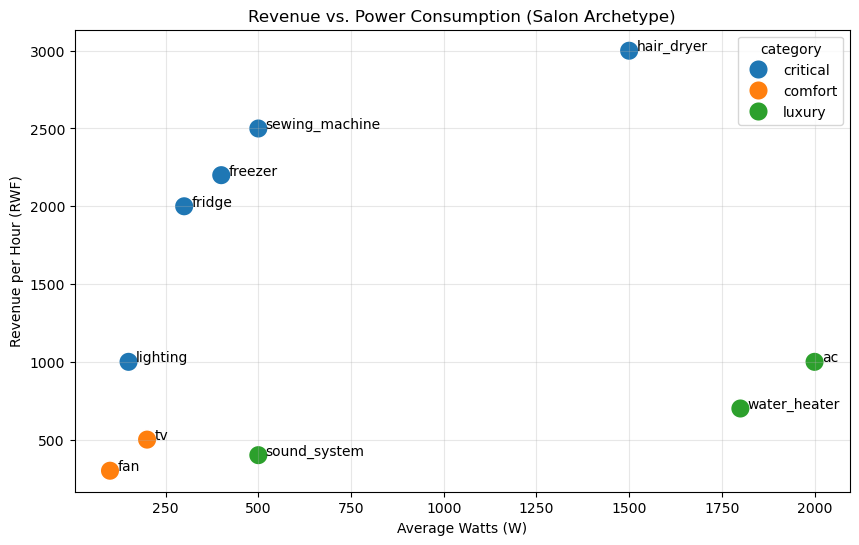

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# If your data is in a DataFrame called df_apps:
df_apps['revenue_if_running_rwf_per_h'] = pd.to_numeric(df_apps['revenue_if_running_rwf_per_h'])
df_apps['watts_avg'] = pd.to_numeric(df_apps['watts_avg'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_apps, 
    x='watts_avg', 
    y='revenue_if_running_rwf_per_h', 
    hue='category',
    s=200
)

# Label the points
for i, row in df_apps.iterrows():
    plt.text(row['watts_avg'] + 20, row['revenue_if_running_rwf_per_h'], row['name'])

plt.title("Revenue vs. Power Consumption (Salon Archetype)")
plt.xlabel("Average Watts (W)")
plt.ylabel("Revenue per Hour (RWF)")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Appliance Catalog Analysis & Business Context

To build an effective **Appliance Prioritization Plan**, we first analyze the salon's assets based on their power consumption, revenue generation, and criticality.

### 3.1 Risk-Revenue Mapping
The following analysis visualizes the trade-off between an appliance's contribution to hourly revenue versus its power demand on the local grid.



### 3.2 Key Insights
* **Critical Protection:** Appliances like the **Fridge**, **Freezer**, and **Sewing Machine** (Top-Left) are high-efficiency revenue earners. Our prioritizer keeps these active the longest.
* **Load Shedding Candidates:** The **AC**, **Water Heater**, and **Sound System** (Bottom-Right) are high-wattage but contribute lower hourly revenue. These are categorized as **Luxury** and are the first to be shed when $P(outage)$ increases.
* **The Revenue Driver:** The **Hair Dryer** is the salon's primary income source (3,000 RWF/hr). Despite high power usage, it is treated as **Critical** to maintain business continuity.
